0.01 1.9104518530058738 0.3685612558359466 0.04093536420886787
0.05 1.0173137219110489 1.258873489853574 0.15250610237639356
0.15 0.3190228212618251 1.9512728908024601 0.25145360830034413
0.2 0.2032893783320566 2.060928327208558 0.2644716864413199
0.25 0.1352630919159358 2.131308222449275 0.26971265670610667
0.3 0.09073757695256567 2.173986495480534 0.2716215331079913
0.35 0.06034214906816759 2.2025445773932137 0.2941715928928534
0.4 0.03902025685761597 2.2184522156556032 0.20667881358196086
0.45 0.02461861679009661 2.2346228558030625 0.2202420986788438
0.5 0.015625 2.241808425568308 0.2723749469966798
0.55 0.01176496355063593 2.2278827462713293 0.22024288150514387
0.6 0.013616105937168364 2.2294653230541597 0.27237495968326475
0.65 0.021267309750149 2.2182395070638905 0.25285184339692574
0.7 0.033042131515203084 2.217251833526276 0.18423888070491676
0.75 0.05882265309080216 2.189711088442034 0.2708008582467886
0.8 0.06681537347802163 2.1620019403821753 0.3767556750482221
0.85 0.167825

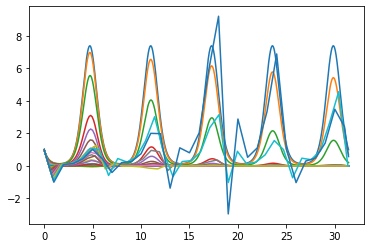

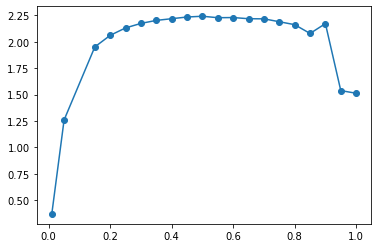

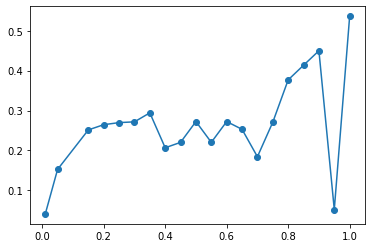

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

def euler(x0, y0, x_end, h):
    xs = [x0]
    ys = [y0]
    x, y = x0, y0
    while x < x_end - 1e-12:
        step = min(h, x_end - x)
        y = y + step * f(x, y)
        x = x + step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

x0, y0 = 0.0, 1.0
x_end = 10 * np.pi
hs = [0.01, 0.05] + [round(h, 2) for h in np.arange(0.15, 1.0001, 0.05)]

avg_y, avg_err, local_err = [], [], []
runs = []

for h in hs:
    xs, ys = euler(x0, y0, x_end, h)
    y_true = exact(xs)
    avg_y.append(np.mean(ys))
    avg_err.append(np.mean(np.abs(ys - y_true)))
    i = np.argmin(np.abs(xs - 15))
    local_err.append(abs(ys[i] - exact(xs[i])))
    runs.append((h, xs, ys))

for i, h in enumerate(hs):
    print(h, avg_y[i], avg_err[i], local_err[i])

x_dense = np.linspace(0, x_end, 3000)
plt.figure()
plt.plot(x_dense, exact(x_dense))
for h, xs, ys in runs:
    plt.plot(xs, ys)
plt.show()

plt.figure()
plt.plot(hs, avg_err, 'o-')
plt.show()

plt.figure()
plt.plot(hs, local_err, 'o-')
plt.show()

The smaller steps sizes for the h makes the Euler method more accurate. In the first plot, the curves with small h values better follow the solution while the large h values drift further. This occurs because Euler's method uses tangent approximation lines which decrease in accuracy during large steps. Furthermore, it can be noted that the average arror increases. Overall, decreasing the value of reduces the total accumulated error.